In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
# import rioxarray
# import xarray
from datetime import timedelta
from sklearn import linear_model

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings("ignore")

import statsmodels.tools.eval_measures as em
from sklearn.metrics import log_loss
import os

import dataretrieval.nwis as nwis
import datetime
from scipy.stats import percentileofscore
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
# from sklearn_quantile import RandomForestQuantileRegressor


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found

In [59]:
USPP = gpd.read_file('../Data/USPP_reach.shp').to_crs('EPSG:26912')
cameras = gpd.read_file('../Data/StreamflowCameras.shp').to_crs('EPSG:26912')

In [198]:
from shapely.geometry import Polygon
def widen_min_rect(geom, width):
    width = width*2
    rect = geom.minimum_rotated_rectangle

    coords = np.array(rect.exterior.coords[:-1])

    # Rectangle edges
    edges = np.roll(coords, -1, axis=0) - coords
    lengths = np.linalg.norm(edges, axis=1)

    # Long edge = length direction; short edge = width direction
    long_i = np.argmax(lengths)
    u = edges[long_i] / lengths[long_i]          # unit vector along rectangle
    v = np.array([-u[1], u[0]])                  # perpendicular unit vector

    center = coords.mean(axis=0)
    length = lengths[long_i]

    half_l = length / 2
    half_w = width / 2

    new_coords = [
        center + half_l*u + half_w*v,
        center + half_l*u - half_w*v,
        center - half_l*u - half_w*v,
        center - half_l*u + half_w*v,
    ]

    return Polygon(new_coords)

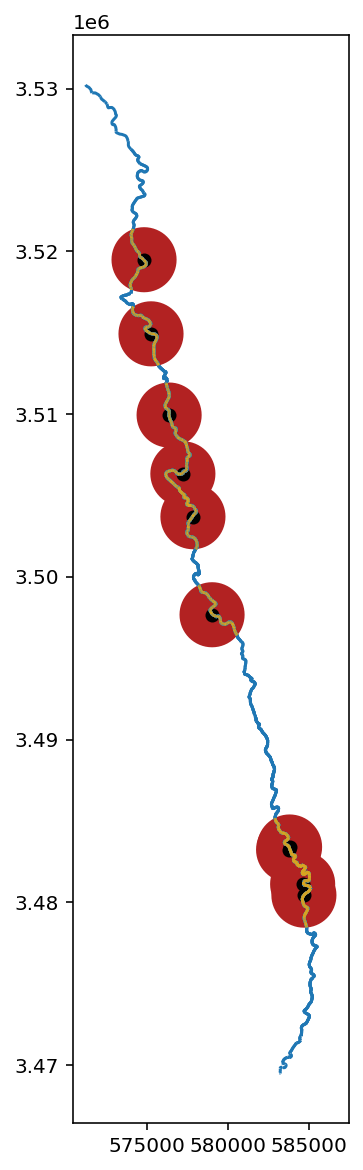

In [202]:
fig,ax = plt.subplots(1,figsize = (5,10))
USPP.plot(ax=ax)
cbuffer = cameras.copy()
cbuffer['geometry'] = cbuffer['geometry'].buffer(2000).make_valid().simplify(2, preserve_topology=True)  # try 1–5 meters
cbuffer.plot(facecolor='firebrick',ax=ax)
cameras.plot(c='k',ax=ax)
kreach = []
cname = []
for i in range(len(cbuffer)):
    cname.append(cbuffer.Name.values[i])
    kreach.append(gpd.overlay(USPP.dissolve(), 
                              cbuffer.iloc[i:i+1], 
                              how='intersection'))
    kreach[i].plot(edgecolor='goldenrod',ax=ax)
    
cameraReaches = gpd.GeoDataFrame(pd.DataFrame.from_dict({'CameraName':cname}),
                                geometry = [k.dissolve().geometry.values[0] for k in kreach])
from shapely.ops import linemerge
cameraReaches['geometry'] = [linemerge(cameraReaches.geometry.values[i]) 
                             for i in range(len(cameraReaches))]

cameraReaches['boundingBox'] = cameraReaches.geometry.minimum_rotated_rectangle()

bufferlist= [50,100,500,1000,5000,10000,50000]
buffers = {b:[] for b in bufferlist}
bufferdiffs = {str(bufferlist[j-1])+'-'+str(bufferlist[j]):[]
              for j in range(1,len(bufferlist))}

for i in range(len(cameraReaches)):
    for j,b in enumerate(bufferlist):
        if b<=100:
            buffers[b].append(cameraReaches.iloc[i:i+1].buffer(b,
                                      cap_style='flat',
                                      join_style="bevel").geometry.values[0])
        else:
            cdf = cameraReaches.iloc[i:i+1]
            cdf['geometry'] = cdf['boundingBox']
            buffers[b].append( widen_min_rect(cameraReaches.iloc[i:i+1].geometry.values[0],
                                              b))
        if j>0:
            s = buffers[b][-1].difference(buffers[bufferlist[j-1]][-1])
            bufferdiffs[str(bufferlist[j-1])+'-'+str(b)].append(s)
for b in buffers.keys():
    cameraReaches['buffer'+str(b)] = buffers[b]
for b in bufferdiffs.keys():
    cameraReaches[b] = bufferdiffs[b]

<Axes: >

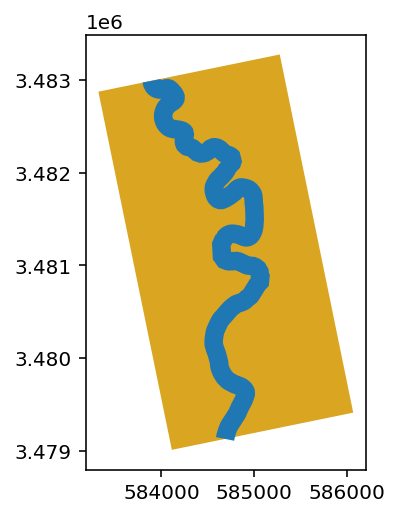

In [200]:
fig,ax = plt.subplots()
i=0
b = 10000
bb = cameraReaches['buffer100']
bb = gpd.GeoDataFrame(pd.DataFrame.from_dict({'Camera':cname}),
                geometry=bb)
bb1 = cameraReaches['buffer1000']
bb1 = gpd.GeoDataFrame(pd.DataFrame.from_dict({'Camera':cname}),
                geometry=bb1)

bb1.iloc[:1].plot(ax=ax,facecolor = 'goldenrod')
bb.iloc[:1].plot(ax=ax)

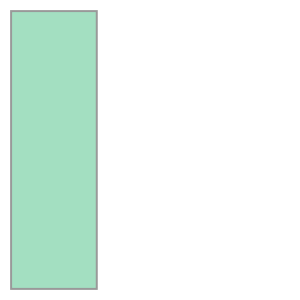

In [201]:
rectangle

<Axes: >

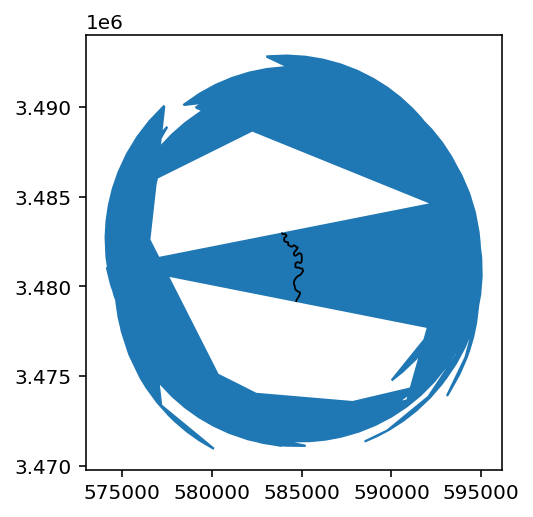

In [161]:
fig,ax = plt.subplots()
gdf.iloc[4:5].plot(ax=ax)
gdf.iloc[:1].plot(facecolor = 'k',ax=ax)

In [220]:
pd.read_csv('../Data/ET/ET_Herefordbuffer50OpenET.csv').dropna()

,Date,ET
0,1999-10-31,52.010862
1,1999-11-30,25.307197
2,1999-12-31,17.071922
3,2000-01-31,22.802056
4,2000-02-29,22.382283
...,...,...
298,2024-08-31,109.842130
299,2024-09-30,97.904772
300,2024-10-31,58.167045
301,2024-11-30,34.916900


In [218]:
cameraReaches

,CameraName,geometry,boundingBox,buffer50,buffer100,buffer500,buffer1000,buffer5000,buffer10000,buffer50000,50-100,100-500,500-1000,1000-5000,5000-10000,10000-50000
0,Hereford Camera,"LINESTRING Z (584686.595 3479125.764 0, 584693...","POLYGON ((585496.351 3479291.848, 584702.806 3...","POLYGON ((584060.5634755901 3482863.628399364,...",POLYGON ((583993.6735358719 3483002.5398832257...,POLYGON ((583808.1247661142 3482977.3386515793...,"POLYGON ((583318.321038786 3482876.878168327, ...",POLYGON ((579399.8912201598 3482073.1943023065...,POLYGON ((574501.8539468772 3481068.5894697807...,"POLYGON ((535317.5557606159 3473031.750809576,...",MULTIPOLYGON (((584006.9910002787 3483005.1171...,MULTIPOLYGON (((584787.7322207708 3483178.2596...,MULTIPOLYGON (((583808.1247661142 3482977.3386...,MULTIPOLYGON (((584297.9284934425 3483077.7991...,MULTIPOLYGON (((579399.8912201598 3482073.1943...,MULTIPOLYGON (((574501.8539468772 3481068.5894...
1,Hunter Camera,"LINESTRING Z (584996.316 3481693.464 0, 584995...","POLYGON ((582678.158 3484927.728, 584634.016 3...","POLYGON ((583674.704691994 3483984.1506105177,...",POLYGON ((583013.8431304997 3484747.7333907764...,"POLYGON ((582440.1753835158 3484792.42986806, ...","POLYGON ((582005.5109391029 3484545.3128497, 5...","POLYGON ((578528.1953837994 3482568.376702819,...","POLYGON ((574181.55093967 3480097.206519218, 5...","POLYGON ((539408.395386635 3460327.845050409, ...",MULTIPOLYGON (((583007.7962025272 3484754.0949...,MULTIPOLYGON (((582824.81051159 3485011.104036...,MULTIPOLYGON (((582440.1753835158 3484792.4298...,MULTIPOLYGON (((582874.8398279287 3485039.5468...,MULTIPOLYGON (((582874.8398279287 3485039.5468...,MULTIPOLYGON (((574181.55093967 3480097.206519...
2,Moson Camera,"LINESTRING Z (580561.244 3496395.626 0, 580557...","POLYGON ((577802.23 3499164.148, 580292.82 349...",POLYGON ((578567.5757378894 3498983.1743666218...,"POLYGON ((578131.5316046191 3499396.422723876,...","POLYGON ((580911.2920127033 3496687.0151736, 5...","POLYGON ((581295.5740171882 3497006.901623812,...","POLYGON ((584369.8300530679 3499565.993225505,...",POLYGON ((588212.6500979176 3502764.8577276217...,POLYGON ((618955.2104567152 3528355.7737445543...,MULTIPOLYGON (((578110.0960129341 3499423.4093...,MULTIPOLYGON (((580640.882842009 3496461.91946...,MULTIPOLYGON (((580911.2920127031 3496687.0151...,MULTIPOLYGON (((580527.0100082182 3496367.1287...,MULTIPOLYGON (((580527.0100082182 3496367.1287...,MULTIPOLYGON (((588212.6500979176 3502764.8577...
3,CharlestonMesquite Camera,"LINESTRING Z (578005.632 3501700.728 0, 578017...","POLYGON ((578443.237 3501776.479, 577776.243 3...",POLYGON ((577276.5918389133 3504995.9927464323...,POLYGON ((576938.7830678992 3505456.8585675177...,"POLYGON ((576882.0525982389 3505474.832490267,...",POLYGON ((576389.3795720314 3505389.5489089186...,POLYGON ((572447.9953623721 3504707.2802581307...,"POLYGON ((567521.265100298 3503854.4444446457,...","POLYGON ((528107.4230037046 3497031.757936766,...",POLYGON ((577044.6114382223 3505560.6226516035...,MULTIPOLYGON (((576973.2077903365 3505490.6118...,MULTIPOLYGON (((577374.7256244463 3505560.1160...,MULTIPOLYGON (((577374.7256244463 3505560.1160...,MULTIPOLYGON (((572447.9953623721 3504707.2802...,MULTIPOLYGON (((577374.7256244463 3505560.1160...
4,Boquillas Camera,"LINESTRING Z (577679.265 3504384.989 0, 577657...","POLYGON ((576166.253 3508325.046, 576167.556 3...","POLYGON ((576899.9835485587 3505561.858449333,...",POLYGON ((576267.5158901328 3506276.1529845926...,POLYGON ((577423.4103659897 3504384.9039347307...,POLYGON ((577923.4103386389 3504385.0693151066...,"POLYGON ((581923.4101198335 3504386.392358117,...","POLYGON ((586923.4098463269 3504388.04616188, ...",POLYGON ((626923.4076582734 3504401.2765919813...,MULTIPOLYGON (((576307.4752041895 3506197.7007...,MULTIPOLYGON (((576423.4104206909 3504384.5731...,MULTIPOLYGON (((576923.4103933403 3504384.7385...,MULTIPOLYGON (((577923.4103386389 3504385.0693...,MULTIPOLYGON (((581923.41011983

In [227]:
b = 10000
bb = cameraReaches['buffer'+str(b)]
bb = gpd.GeoDataFrame(pd.DataFrame.from_dict({'Camera':cname}),
                geometry=bb)
bb.dissolve().to_file('../Data/AOI_SPRNCA.shp')

In [236]:
Dtest = gpd.read_file('../Data/DeficitTestPoints.shp')
Dtest['x'] = Dtest.geometry.x
Dtest['y'] = Dtest.geometry.y
Dtest = Dtest[['Name','x','y']]

In [242]:
dataJawad = cameras[['Name','geometry']].to_crs('EPSG:4326')
dataJawad['x'] = dataJawad.geometry.x
dataJawad['y'] = dataJawad.geometry.y
dataJawad = dataJawad[['Name','x','y']]
pd.concat([dataJawad,Dtest]).reset_index().drop(columns='index').to_csv('../Data/pts_for_Jawad.csv',index=False)

In [260]:
Jlabel = pd.concat([dataJawad,Dtest]).reset_index().drop(columns='index')
Jlabel

,Name,x,y
0,Hereford Camera,-110.109676,31.461756
1,Hunter Camera,-110.118590,31.480882
2,Moson Camera,-110.166932,31.611438
3,CharlestonMesquite Camera,-110.178841,31.665863
4,Boquillas Camera,-110.185152,31.689704
5,Fairbank Camera,-110.193796,31.722309
6,Contention Camera,-110.205148,31.767399
7,St.David Camera,-110.209318,31.808501
8,Untitled Placemark,-110.108923,31.455625
9,Untitled Placemark,-110.117945,31.482375


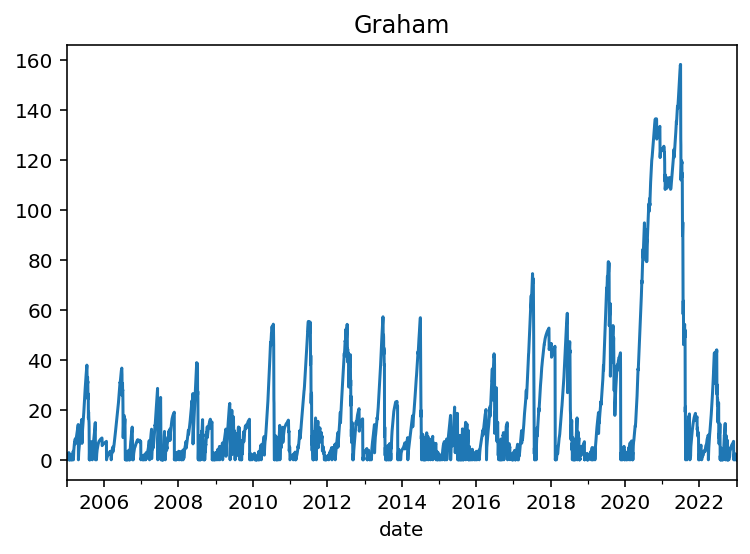

In [266]:
for ii in [21]:#range(23):
    ii += 1
    ET = pd.read_csv('../Data/Jawad_ET/J'+str(ii)+'.csv')
    ET['date'] = pd.to_datetime(ET.date)
    ET.set_index('date',inplace=True)

    def calc_deficit(D0,P,ET):
        deltaS = P - ET
        if deltaS>0:
            D0 -= deltaS
            if D0<0:
                D0 = 0
            return D0
        else:
            D0 -= deltaS
            return D0

    D = [0]
    for i in range(len(ET)):
        D.append(calc_deficit(D[-1],ET.Precip.values[i],
                             ET.LE_model.values[i]*0.0353))
    ET['deficit'] = D[1:]

    ET.deficit.plot()
    plt.title(Jlabel.Name.values[ii-1])
    plt.show()

In [267]:
(ET.groupby(ET.index.year).LE_model.sum()*0.0353)

date
2005    250.936782
2006    242.390830
2007    317.320779
2008    341.638604
2009    335.938108
2010    315.018659
2011    300.305931
2012    294.295040
2013    317.616837
2014    307.967859
2015    416.304755
2016    336.590170
2017    260.533332
2018    345.717033
2019    307.254775
2020    288.551918
2021    304.448769
2022    396.446914
Name: LE_model, dtype: float64

In [271]:
CAsites = gpd.read_file('../Data/CAsites.geojson')
CAsites['x'] = CAsites.geometry.x
CAsites['y'] = CAsites.geometry.y
CAsites[['site','x','y']].to_csv('../Data/CAsites.csv')

In [8]:
ETdata.head()

,date,DW_SW,DW_LW,Air_Temp,SPFH,Pa,Precip,WS_u,WS_v,Albedo,LE_model,RH
0,2005-01-01,60.875001,269.320837,272.212504,0.003788,79900.83333,1.5,-0.908333,3.300000,0.394936,0.014751,0.939362
1,2005-01-02,56.675001,264.641671,271.679171,0.003692,79840.00000,3.0,-1.604167,2.858333,0.390450,0.143713,0.951900
2,2005-01-03,82.366668,266.587504,270.887504,0.003504,79513.75000,20.2,-1.654167,3.400000,0.392795,10.506716,0.954730
3,2005-01-04,88.050001,264.520837,270.620837,0.003458,79244.58333,8.6,1.316667,0.000000,0.394453,5.004464,0.958049
4,2005-01-05,124.095835,225.870837,270.358337,0.003317,80049.58333,1.1,0.008333,1.433333,0.392602,1.248544,0.946659


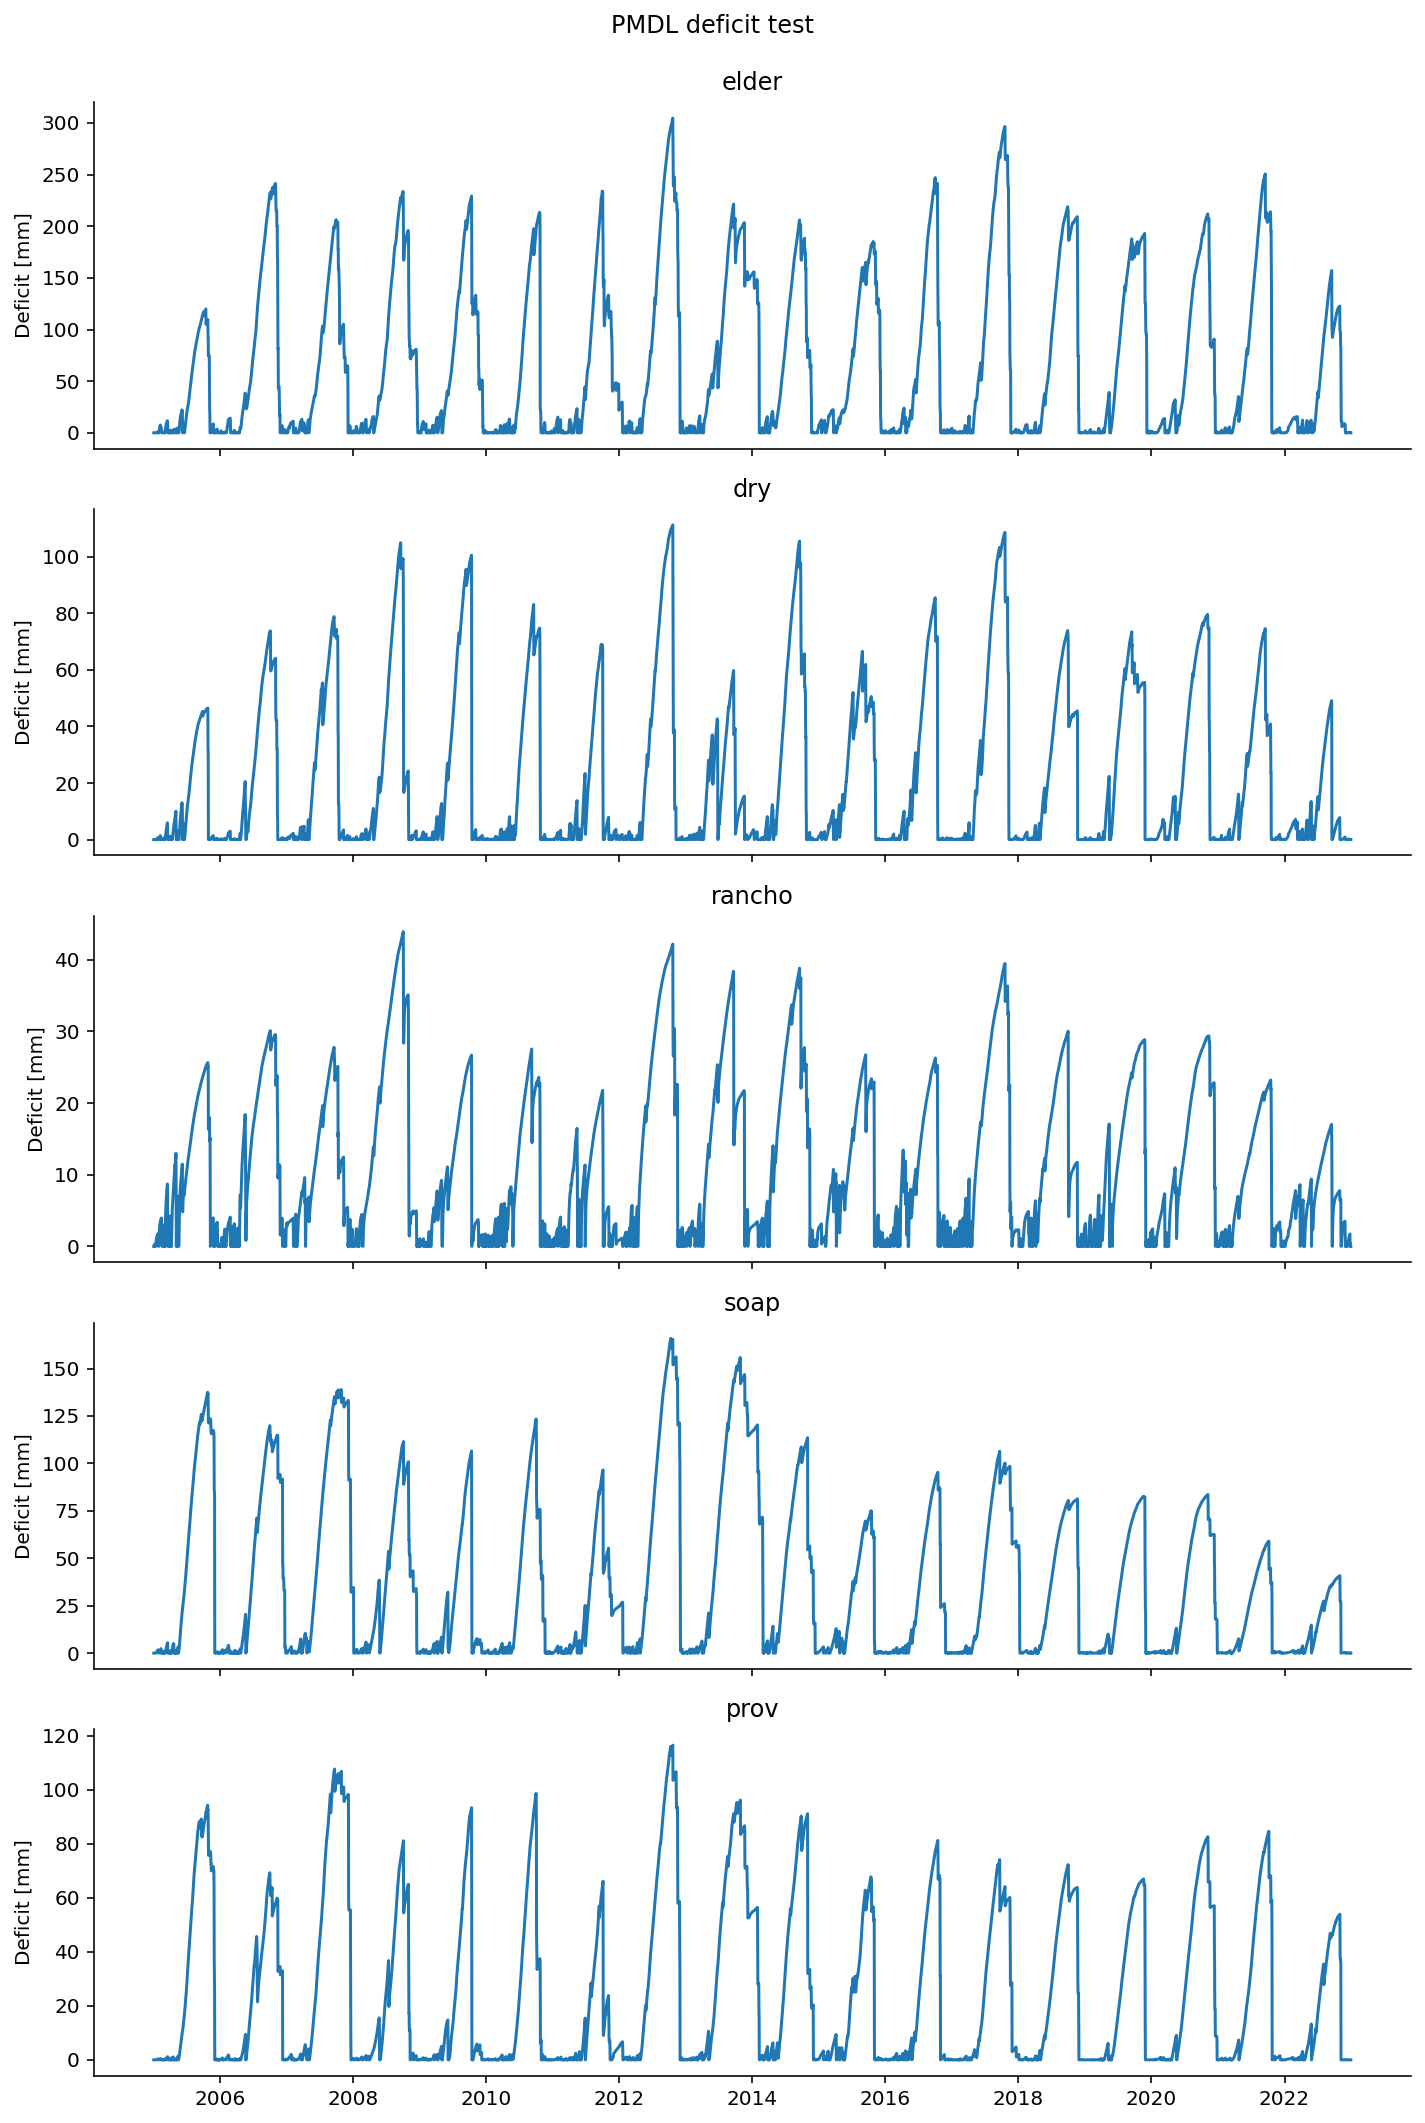

In [19]:
Jsites = pd.read_csv('../Data/Dana_CAsites.csv')
fig, axs = plt.subplots(len(Jsites),figsize = (10,3*len(Jsites)),
                       sharex=True)
for i in Jsites.index:
    ETdata = pd.read_csv('../Data/Dana_Results_CA/'+Jsites.ID.values[i]+'.csv')
    ETdata['date'] = pd.to_datetime(ETdata['date'])
    ETdata.set_index('date',inplace=True)
    deficit = [0]
    for j in range(len(ETdata)):
        d = deficit[-1]-ETdata.Precip.values[j]+ETdata.LE_model.values[j]*0.0353
        if d<0:
            d = 0
        deficit.append(d)
    ETdata['D'] = deficit[1:]
    ax = axs[i]
    ax.plot(ETdata.D)
    ax.set_title(Jsites.site.values[i])
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylabel('Deficit [mm]')
    
fig.suptitle('PMDL deficit test\n')
fig.tight_layout()
plt.savefig('deficit_test.png',format='png',dpi=300,bbox_inches='tight')